# Глава 6. Тонкая настройка для классификации текста

In [1]:
pip install matplotlib numpy tiktoken torch tensorflow pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from importlib.metadata import version

pkgs = ["matplotlib",  # Библиотека для построения графиков
        "numpy",       # Зависимость для PyTorch и TensorFlow
        "tiktoken",    # Токенизатор
        "torch",       # Библиотека для глубокого обучения
        "tensorflow",  # Для предобученных весов OpenAI
        "pandas"       # Загрузка наборов данных
       ]
for p in pkgs:
    print(f"{p} версия: {version(p)}")

matplotlib версия: 3.10.9
numpy версия: 2.4.4
tiktoken версия: 0.12.0
torch версия: 2.12.0
tensorflow версия: 2.21.0
pandas версия: 3.0.3


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/01.webp" width=800px>

&nbsp;
### 6.1. Различные категории тонкой настройки

- Наиболее распространёнными способами тонкой настройки языковых моделей являются инструктивная тонкая настройка и тонкая настройка для классификации
- Инструктивная тонкая настройка, изображённая ниже, является темой следующей главы

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/02.webp" width=800px>

- Тонкая настройка для классификации — тема этой главы. Это процедура, с которой вы, возможно, уже знакомы, если имеете опыт в машинном обучении: она похожа, например, на обучение свёрточной сети распознаванию рукописных цифр
- При тонкой настройке для классификации у нас есть определённое количество меток классов (например, «спам» и «не спам»), которые модель может выдавать на выходе
- Модель, дообученная для классификации, может предсказывать только те классы, которые она видела во время обучения (например, «спам» или «не спам»), в то время как модель с инструктивной тонкой настройкой обычно способна выполнять множество задач
- Модель, дообученную для классификации, можно рассматривать как очень узкоспециализированную модель; на практике создать специализированную модель гораздо проще, чем модель-универсала, хорошо справляющуюся со множеством различных задач

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/03.webp" width=800px>

&nbsp;
### 6.2. Подготовка данных

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/04.webp" width=800px>

- В этом разделе мы подготавливаем набор данных, который будем использовать для тонкой настройки классификации.
- Мы используем набор данных, состоящий из спам- и не спам-сообщений, чтобы дообучить LLM классифицировать их.
- Сначала мы скачиваем и распаковываем набор данных.

In [3]:
import requests
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"


def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} уже существует. Пропускаем скачивание и распаковку.")
        return

    # Скачивание файла
    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()
    with open(zip_path, "wb") as out_file:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                out_file.write(chunk)

    # Распаковка файла
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Добавляем расширение .tsv
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"Файл скачан и сохранён как {data_file_path}")


try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (requests.exceptions.RequestException, TimeoutError) as e:
    print(f"Основной URL не сработал: {e}. Пробуем резервный URL...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)



# Изначально в книге использовался код ниже.
# Однако urllib использует старые настройки протокола,
# что может вызывать проблемы у некоторых читателей, использующих VPN.
# Версия с `requests` более надёжна в этом отношении.

"""
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} уже существует. Пропускаем скачивание и распаковку.")
        return

    # Скачивание файла
    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    # Распаковка файла
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Добавляем расширение .tsv
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"Файл скачан и сохранён как {data_file_path}")

try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (urllib.error.HTTPError, urllib.error.URLError, TimeoutError) as e:
    print(f"Основной URL не сработал: {e}. Пробуем резервный URL...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
"""

sms_spam_collection\SMSSpamCollection.tsv уже существует. Пропускаем скачивание и распаковку.


'\nimport urllib.request\nimport zipfile\nimport os\nfrom pathlib import Path\n\nurl = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"\nzip_path = "sms_spam_collection.zip"\nextracted_path = "sms_spam_collection"\ndata_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"\n\ndef download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):\n    if data_file_path.exists():\n        print(f"{data_file_path} уже существует. Пропускаем скачивание и распаковку.")\n        return\n\n    # Скачивание файла\n    with urllib.request.urlopen(url) as response:\n        with open(zip_path, "wb") as out_file:\n            out_file.write(response.read())\n\n    # Распаковка файла\n    with zipfile.ZipFile(zip_path, "r") as zip_ref:\n        zip_ref.extractall(extracted_path)\n\n    # Добавляем расширение .tsv\n    original_file_path = Path(extracted_path) / "SMSSpamCollection"\n    os.rename(original_file_path, data_file_path)\n    print(f"Файл скачан и со

- Набор данных сохранён в виде текстового файла с табуляцией в качестве разделителя, который мы можем загрузить в DataFrame библиотеки pandas

In [4]:
import pandas as pd

df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


- Когда мы проверяем распределение классов, мы видим, что данные содержат "ham" (то есть «не спам») гораздо чаще, чем "spam"

In [5]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


- Для простоты, а также потому, что для учебных целей мы в любом случае предпочитаем небольшой набор данных (это позволит быстрее выполнить тонкую настройку LLM), мы делаем подвыборку (недостаточную выборку) набора данных так, чтобы он содержал по 747 экземпляров каждого класса

In [6]:
def create_balanced_dataset(df):
    
    # Подсчитываем количество экземпляров "spam"
    num_spam = df[df["Label"] == "spam"].shape[0]
    
    # Случайным образом выбираем экземпляры "ham" в количестве, равном числу "spam"
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    
    # Объединяем подвыборку "ham" со "spam"
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])

    return balanced_df


balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


- Далее мы заменяем строковые метки классов "ham" и "spam" на целочисленные метки 0 и 1:

In [7]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})    

In [8]:
balanced_df

,Label,Text
4307,0,Awww dat is sweet! We can think of something t...
4138,0,Just got to &lt;#&gt;
4831,0,"The word ""Checkmate"" in chess comes from the P..."
4461,0,This is wishing you a great day. Moji told me ...
5440,0,Thank you. do you generally date the brothas?
...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...


- Теперь давайте определим функцию, которая случайным образом разделяет набор данных на обучающую, валидационную и тестовую подвыборки

In [9]:
def random_split(df, train_frac, validation_frac):
    # Перемешиваем весь DataFrame
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Вычисляем индексы разбиения
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # Разбиваем DataFrame
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)
# Размер тестовой выборки подразумевается равным 0.2 как остаток

train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

&nbsp;

### 6.3. Создание загрузчиков данных

- Обратите внимание, что текстовые сообщения имеют разную длину; если мы хотим объединить несколько обучающих примеров в один пакет, нам необходимо либо
  1. обрезать все сообщения до длины самого короткого сообщения в наборе данных или пакете
  2. либо дополнить все сообщения до длины самого длинного сообщения в наборе данных или пакете

- Мы выбираем вариант 2 и дополняем все сообщения до самого длинного сообщения в наборе данных
- Для этого мы используем `<|endoftext|>` в качестве токена заполнения

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/06.webp" width=800px>

In [10]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


- Класс `SpamDataset` ниже определяет самую длинную последовательность в обучающем наборе данных и добавляет токен заполнения к остальным, чтобы они соответствовали этой длине последовательности

In [11]:
import torch
from torch.utils.data import Dataset


class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # Предварительно токенизируем тексты
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # Обрезаем последовательности, если они длиннее max_length
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        # Дополняем последовательности до самой длинной
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length
        # Примечание: более идиоматичный способ реализовать этот метод —
        # следующий, который также используется в следующей главе:
        # return max(len(encoded_text) for encoded_text in self.encoded_texts)

In [12]:
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

print(train_dataset.max_length)

120


- Мы также дополняем валидационный и тестовый наборы до самой длинной обучающей последовательности
- Обратите внимание, что образцы валидационного и тестового наборов, которые длиннее самого длинного обучающего примера, обрезаются посредством `encoded_text[:self.max_length]` в коде `SpamDataset`
- Такое поведение является полностью опциональным, и всё также будет хорошо работать, если мы установим `max_length=None` как для валидационного, так и для тестового наборов

In [13]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

 ---

## Упражнение 6.1. Увеличение длины контекста

Мы можем дополнить входные данные до максимального количества токенов, поддерживаемого моделью, установив максимальную длину равной 1024:

```python
max_length = 1024

train_dataset = SpamDataset(base_path / "train.csv", max_length=max_length, tokenizer=tokenizer)
val_dataset = SpamDataset(base_path / "validation.csv", max_length=max_length, tokenizer=tokenizer)
test_dataset = SpamDataset(base_path / "test.csv", max_length=max_length, tokenizer=tokenizer)
```

или, что эквивалентно, мы можем определить `max_length` через:

```python
max_length = model.pos_emb.weight.shape[0]
```

или

```python
max_length = BASE_CONFIG["context_length"]
```

Для удобства можно запустить этот эксперимент с помощью

```bash
python additional-experiments.py --context_length "model_context_length"
```

используя код из папки [../02_bonus_additional-experiments](../02_bonus_additional-experiments), что приводит к существенно худшей точности на тестовом наборе — 78,33% (против 95,67% в основной главе)

---

- Далее мы используем набор данных для создания экземпляров загрузчиков данных, что аналогично созданию загрузчиков данных в предыдущих главах

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/07.webp" width=800px>

In [14]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

- В качестве проверочного шага мы итерируем по загрузчикам данных и убеждаемся, что каждый пакет содержит по 8 обучающих примеров, где каждый обучающий пример состоит из 120 токенов

In [15]:
print("Загрузчик обучающих данных:")
for input_batch, target_batch in train_loader:
    pass

print("Размеры входного пакета:", input_batch.shape)
print("Размеры пакета меток:", target_batch.shape)

Загрузчик обучающих данных:
Размеры входного пакета: torch.Size([8, 120])
Размеры пакета меток: torch.Size([8])


- Наконец, давайте выведем общее количество пакетов в каждом наборе данных

In [16]:
print(f"{len(train_loader)} обучающих пакетов")
print(f"{len(val_loader)} валидационных пакетов")
print(f"{len(test_loader)} тестовых пакетов")

130 обучающих пакетов
19 валидационных пакетов
38 тестовых пакетов


&nbsp;
### 6.4 Инициализация модели с предварительно обученными весами

- В этом разделе мы инициализируем предобученную модель, с которой работали в предыдущей главе

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/08.webp" width=800px>

In [17]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # Размер словаря
    "context_length": 1024,  # Длина контекста
    "drop_rate": 0.0,        # Коэффициент дропаута
    "qkv_bias": True         # Смещение для query-key-value
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Длина набора данных {train_dataset.max_length} превышает "
    f"длину контекста модели {BASE_CONFIG['context_length']}. "
    f"Переинициализируйте наборы данных с "
    f"`max_length={BASE_CONFIG['context_length']}`"
)

In [18]:
# Импорт функций для скачивания и загрузки GPT-2,
# а также классов модели и функции загрузки весов
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

# Извлечение размера модели из строки CHOOSE_MODEL
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

# Скачивание и загрузка параметров предобученной GPT-2
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")

# Создание экземпляра модели GPT с заданной конфигурацией
model = GPTModel(BASE_CONFIG)

# Загрузка предобученных весов в модель
load_weights_into_gpt(model, params)

# Перевод модели в режим оценки (eval)
model.eval();

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 77.0kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 844kiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 89.9kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [04:13<00:00, 1.96MiB/s]  
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 2.61MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 641kiB/s] 
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 513kiB/s] 


- Чтобы убедиться, что модель загружена корректно, давайте дважды проверим, генерирует ли она связный текст

In [19]:
from previous_chapters import (
    generate_text_simple,
    text_to_token_ids,
    token_ids_to_text
)

# Alternatively:
# from llms_from_scratch.ch05 import (
#    generate_text_simple,
#    text_to_token_ids,
#    token_ids_to_text
# )


text_1 = "Every effort moves you"

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


- Прежде чем дообучать модель как классификатор, давайте посмотрим, сможет ли модель, возможно, уже классифицировать спам-сообщения с помощью промптинга

In [20]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


- Как мы видим, модель не очень хорошо справляется с выполнением инструкций
- Это ожидаемо, поскольку она была только предобучена и не проходила инструктивную тонкую настройку

&nbsp;
### 6.5 Добавление цели классификации

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/09.webp" width=800px>

- В этом разделе мы модифицируем предобученную LLM, чтобы подготовить её к тонкой настройке для классификации
- Давайте сначала взглянем на архитектуру модели

In [21]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

- Выше мы можем видеть аккуратно представленную архитектуру
- Цель состоит в том, чтобы заменить и дообучить выходной слой
- Чтобы достичь этого, мы сначала замораживаем модель, то есть делаем все слои необучаемыми

In [22]:
for param in model.parameters():
    param.requires_grad = False

- Затем мы заменяем выходной слой (`model.out_head`), который изначально отображает входы слоя в 50 257 измерений (размер словаря)
- Поскольку мы дообучаем модель для бинарной классификации (предсказание 2 классов: «спам» и «не спам»), мы можем заменить выходной слой, как показано ниже, который по умолчанию будет обучаемым
- Обратите внимание, что мы используем `BASE_CONFIG["emb_dim"]` (который равен 768 в модели `"gpt2-small (124M)"`), чтобы сохранить приведённый ниже код более общим

In [23]:
torch.manual_seed(123)

num_classes = 2
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

- Технически достаточно обучать только выходной слой.
- Однако, эксперименты показывают, что дообучение дополнительных слоёв может заметно улучшить производительность. Статья [Finetuning Large Language Models](https://magazine.sebastianraschka.com/p/finetuning-large-language-models)
- Поэтому мы также делаем обучаемыми последний трансформерный блок и последний модуль `LayerNorm`, соединяющий последний трансформерный блок с выходным слоем

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/10.webp" width=800px>

In [24]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

 ---

 ## Упражнение 6.2. Тонкая настройка всей модели

Вместо того чтобы дообучать только последний трансформерный блок, мы можем дообучить всю модель целиком, удалив из кода следующие строки:

```python
for param in model.parameters():
    param.requires_grad = False
```

Для удобства можно запустить этот эксперимент с помощью

```bash
python additional-experiments.py --trainable_layers all
```

используя код из папки [../02_bonus_additional-experiments](../02_bonus_additional-experiments), что приводит к улучшению точности на тестовом наборе на 1% — до 96,67% (против 95,67% в основной главе).

 ---

- Мы по-прежнему можем использовать эту модель аналогично тому, как делали это в предыдущих главах
- Например, давайте подадим ей на вход какой-нибудь текст

In [25]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Входные данные:", inputs)
print("Размеры входных данных:", inputs.shape) # форма: (batch_size, num_tokens)

Входные данные: tensor([[5211,  345,  423,  640]])
Размеры входных данных: torch.Size([1, 4])


- Отличие от предыдущих глав заключается в том, что теперь модель имеет два выходных измерения вместо 50 257

In [26]:
with torch.no_grad():
    outputs = model(inputs)

print("Выходные данные:\n", outputs)
print("Размеры выходных данных:", outputs.shape) # форма: (batch_size, num_tokens, num_classes)

Выходные данные:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Размеры выходных данных: torch.Size([1, 4, 2])


- Как обсуждалось в предыдущих главах, для каждого входного токена существует один выходной вектор
- Поскольку мы подали модели текстовый образец с 4 входными токенами, выходные данные выше состоят из четырёх 2-мерных выходных векторов

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/11.webp" width=800px>

- В главе 3 мы обсуждали механизм внимания, который связывает каждый входной токен с каждым другим входным токеном
- В главе 3 мы также ввели каузальную маску внимания, используемую в GPT-подобных моделях; эта каузальная маска позволяет текущему токену учитывать только текущую и предыдущие позиции токенов
- На основе этого каузального механизма внимания 4-й (последний) токен содержит наибольшее количество информации среди всех токенов, поскольку это единственный токен, который включает информацию обо всех остальных токенах
- Следовательно, нас особенно интересует этот последний токен, который мы будем дообучать для задачи классификации спама

In [27]:
print("Последний выходной токен:", outputs[:, -1, :])

Последний выходной токен: tensor([[-3.5983,  3.9902]])


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/12.webp" width=800px>

 ---

 ## Упражнение 6.3. Тонкая настройка первого и по последнего токенов

 Вместо тонкой настройки по последнему выходному токену мы можем выполнить тонкую настройку по первому выходному токену, заменив

```python
model(input_batch)[:, -1, :]
```

на

```python
model(input_batch)[:, 0, :]
```

повсюду в коде.

Для удобства вы можете запустить этот эксперимент с помощью

```
python additional-experiments.py --trainable_token first
```

используя код из папки [../02_bonus_additional-experiments](../02_bonus_additional-experiments), что приводит к существенно худшей точности на тестовом наборе — 75,00% (против 95,67% в основной главе).

---

&nbsp;
### 6.6. Расчет потерь и точности классификации

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/13.webp" width=800px>

- Прежде чем объяснять вычисление функции потерь, давайте кратко рассмотрим, как выходные данные модели преобразуются в метки классов

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/14.webp" width=800px>

In [28]:
print("Последний выходной токен:", outputs[:, -1, :])

Последний выходной токен: tensor([[-3.5983,  3.9902]])


- Мы преобразуем выходные данные (логиты) в вероятностные оценки с помощью функции `softmax`, а затем получаем индекс позиции наибольшего вероятностного значения с помощью функции `argmax`

In [29]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("Метка класса:", label.item())

Метка класса: 1


- Обратите внимание, что функция softmax здесь необязательна, поскольку наибольшие выходные значения соответствуют наибольшим вероятностным оценкам

In [30]:
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print("Метка класса:", label.item())

Метка класса: 1


- Мы можем применить эту концепцию для вычисления так называемой точности классификации, которая определяет процент правильных предсказаний в заданном наборе данных
- Чтобы вычислить точность классификации, мы можем применить приведённый выше код предсказания на основе `argmax` ко всем примерам в наборе данных и вычислить долю правильных предсказаний следующим образом:

In [31]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]  # Логиты последнего выходного токена
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples

- Давайте применим эту функцию для вычисления точности классификации для различных наборов данных:

In [32]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Используйте PyTorch 2.9 или новее для стабильных результатов mps
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Устройство:", device)

model.to(device) # для классов nn.Module присваивание model = model.to(device) не требуется

torch.manual_seed(123) # Для воспроизводимости из-за перемешивания в загрузчике обучающих данных

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Точность на обучающем наборе: {train_accuracy*100:.2f}%")
print(f"Точность на валидационном наборе: {val_accuracy*100:.2f}%")
print(f"Точность на тестовом наборе: {test_accuracy*100:.2f}%")

Устройство: cpu
Точность на обучающем наборе: 46.25%
Точность на валидационном наборе: 45.00%
Точность на тестовом наборе: 48.75%


- Как мы видим, точность предсказаний не очень высока, поскольку мы ещё не выполнили тонкую настройку модели

- Прежде чем мы сможем приступить к тонкой настройке (обучению), мы сначала должны определить функцию потерь, которую будем оптимизировать в процессе обучения
- Цель состоит в том, чтобы максимизировать точность классификации спама модели; однако точность классификации не является дифференцируемой функцией
- Поэтому вместо этого мы минимизируем кросс-энтропийную функцию потерь в качестве замены для максимизации точности классификации (вы можете узнать больше об этой теме в лекции 8 моего бесплатного курса [Introduction to Deep Learning](https://sebastianraschka.com/blog/2021/dl-course.html#l08-multinomial-logistic-regression--softmax-regression))

- Функция `calc_loss_batch` здесь та же, за исключением того, что нас интересует оптимизация только последнего токена `model(input_batch)[:, -1, :]` вместо всех токенов `model(input_batch)`

In [33]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]  # Логиты последнего выходного токена
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

Функция `calc_loss_loader` точно такая же

In [34]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Уменьшаем количество пакетов до общего числа пакетов в загрузчике данных,
        # если num_batches превышает количество пакетов в загрузчике данных
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

- Используя `calc_loss_loader`, мы вычисляем начальные значения функции потерь на обучающем, валидационном и тестовом наборах перед началом обучения

In [35]:
with torch.no_grad(): # Отключаем отслеживание градиентов для эффективности, так как мы пока не обучаем
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Потери на обучающем наборе: {train_loss:.3f}")
print(f"Потери на валидационном наборе: {val_loss:.3f}")
print(f"Потери на тестовом наборе: {test_loss:.3f}")

Потери на обучающем наборе: 2.453
Потери на валидационном наборе: 2.583
Потери на тестовом наборе: 2.322


- В следующем разделе мы обучим модель, чтобы улучшить значения функции потерь и, как следствие, точность классификации

&nbsp;
### 6.7. Тонкая настройка модели на данных с метками

- В этом разделе мы определяем и используем функцию обучения для повышения точности классификации модели
- Функция `train_classifier_simple` ниже практически идентична функции `train_model_simple`, которую мы использовали для предобучения модели
- Единственные два отличия заключаются в том, что теперь мы 
  1. отслеживаем количество просмотренных обучающих примеров (`examples_seen`) вместо количества просмотренных токенов
  2. вычисляем точность после каждой эпохи вместо вывода образца текста после каждой эпохи

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/15.webp" width=800px>

In [36]:
# В целом то же самое, что и `train_model_simple` в главе 5
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                            eval_freq, eval_iter):
    # Инициализируем списки для отслеживания потерь и просмотренных примеров
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    # Основной цикл обучения
    for epoch in range(num_epochs):
        model.train()  # Переводим модель в режим обучения

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Обнуляем градиенты потерь с предыдущей итерации пакета
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Вычисляем градиенты потерь
            optimizer.step() # Обновляем веса модели, используя градиенты потерь
            examples_seen += input_batch.shape[0] # Новое: отслеживаем примеры вместо токенов
            global_step += 1

            # Опциональный шаг оценки
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Эп {epoch+1} (Шаг {global_step:06d}): "
                      f"Потери на обучении {train_loss:.3f}, Потери на валидации {val_loss:.3f}")

        # Вычисляем точность после каждой эпохи
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"Точность на обучении: {train_accuracy*100:.2f}% | ", end="")
        print(f"Точность на валидации: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

- Функция `evaluate_model`, используемая в `train_classifier_simple`, та же

In [37]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

- Обучение занимает около 5 минут на ноутбуке M3 MacBook Air и менее половины минуты на GPU V100 или A100

In [38]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Обучение завершено за {execution_time_minutes:.2f} минут.")

Эп 1 (Шаг 000000): Потери на обучении 2.153, Потери на валидации 2.392
Эп 1 (Шаг 000050): Потери на обучении 0.617, Потери на валидации 0.637
Эп 1 (Шаг 000100): Потери на обучении 0.523, Потери на валидации 0.557
Точность на обучении: 70.00% | Точность на валидации: 72.50%
Эп 2 (Шаг 000150): Потери на обучении 0.561, Потери на валидации 0.489
Эп 2 (Шаг 000200): Потери на обучении 0.419, Потери на валидации 0.397
Эп 2 (Шаг 000250): Потери на обучении 0.409, Потери на валидации 0.353
Точность на обучении: 82.50% | Точность на валидации: 85.00%
Эп 3 (Шаг 000300): Потери на обучении 0.333, Потери на валидации 0.320
Эп 3 (Шаг 000350): Потери на обучении 0.340, Потери на валидации 0.306
Точность на обучении: 90.00% | Точность на валидации: 90.00%
Эп 4 (Шаг 000400): Потери на обучении 0.136, Потери на валидации 0.200
Эп 4 (Шаг 000450): Потери на обучении 0.153, Потери на валидации 0.132
Эп 4 (Шаг 000500): Потери на обучении 0.222, Потери на валидации 0.137
Точность на обучении: 100.00% | Точн

- Используем matplotlib для построения графика функции потерь для обучающего и валидационного наборов

In [ ]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Строим график потерь на обучении и валидации по эпохам
    ax1.plot(epochs_seen, train_values, label=f"Обучающий набор {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Валидационный набор {label}")
    ax1.set_xlabel("Эпохи")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Создаём вторую ось x для просмотренных примеров
    ax2 = ax1.twiny()  # Создаём вторую ось x, которая делит ту же ось y
    ax2.plot(examples_seen, train_values, alpha=0)  # Невидимый график для выравнивания меток
    ax2.set_xlabel("Просмотрено примеров")

    fig.tight_layout()  # Настраиваем расположение, чтобы освободить место
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

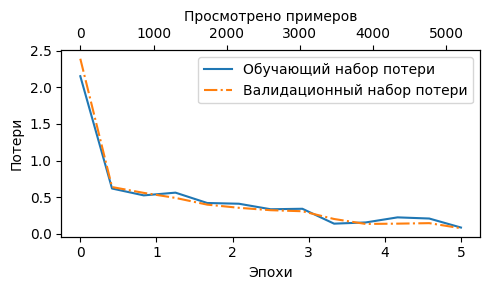

In [40]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

- Выше, судя по нисходящему наклону, мы видим, что модель обучается хорошо
- Кроме того, тот факт, что потери на обучающем и валидационном наборах очень близки, указывает на то, что модель не склонна к переобучению на обучающих данных
- Аналогично, ниже мы можем построить график точности

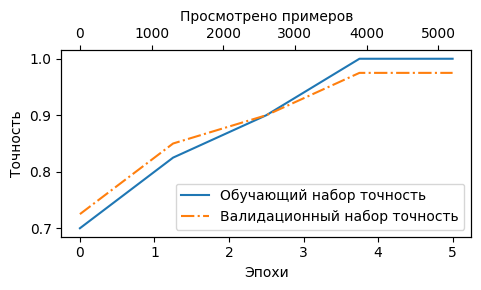

In [ ]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

- Основываясь на графике точности выше, мы видим, что модель достигает относительно высокой точности на обучающем и валидационном наборах после эпох 4 и 5
- Однако следует помнить, что ранее в функции обучения мы указали `eval_iter=5`, что означает, что мы лишь оценили производительность на обучающем и валидационном наборах
- Мы можем вычислить производительность на полном обучающем, валидационном и тестовом наборах следующим образом

In [42]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Точность на обучающем наборе: {train_accuracy*100:.2f}%")
print(f"Точность на валидационном наборе: {val_accuracy*100:.2f}%")
print(f"Точность на тестовом наборе: {test_accuracy*100:.2f}%")

Точность на обучающем наборе: 97.21%
Точность на валидационном наборе: 97.32%
Точность на тестовом наборе: 95.67%


- Мы видим, что производительность на обучающем и валидационном наборах практически идентична
- Однако, учитывая немного более низкую производительность на тестовом наборе, мы видим, что модель в очень малой степени переобучается на обучающих данных, а также на валидационных данных, которые использовались для подбора некоторых гиперпараметров, таких как скорость обучения
- Это, однако, нормально, и этот разрыв потенциально можно было бы ещё уменьшить, увеличив коэффициент дропаута модели (`drop_rate`) или параметр `weight_decay` в настройках оптимизатора

&nbsp;
### 6.8. Использование LLM в качестве классификатора спама

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/18.webp" width=800px>

- Наконец, давайте применим дообученную модель GPT на практике
- Функция `classify_review` ниже реализует шаги предобработки данных, аналогичные тем, что мы реализовали ранее в `SpamDataset`
- Затем функция возвращает предсказанную целочисленную метку класса от модели и возвращает соответствующее имя класса

In [43]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    # Подготавливаем входные данные для модели
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]
    # Примечание: в книге это изначально было ошибочно написано как pos_emb.weight.shape[1]
    # Это не ломало код, но привело бы к ненужному усечению (до 768 вместо 1024)

    # Обрезаем последовательности, если они слишком длинные
    input_ids = input_ids[:min(max_length, supported_context_length)]
    assert max_length is not None, (
        "max_length должен быть указан. Если вы хотите использовать полный контекст модели, "
        "передайте max_length=model.pos_emb.weight.shape[0]."
    )
    assert max_length <= supported_context_length, (
        f"max_length ({max_length}) превышает поддерживаемую моделью длину контекста ({supported_context_length})."
    )    
    # Альтернативно, более надёжная версия — следующая, которая лучше обрабатывает случай max_length=None
    # max_len = min(max_length,supported_context_length) if max_length else supported_context_length
    # input_ids = input_ids[:max_len]
    
    # Дополняем последовательности до самой длинной
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0) # добавляем размерность пакета

    # Инференс модели
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # Логиты последнего выходного токена
    predicted_label = torch.argmax(logits, dim=-1).item()

    # Возвращаем результат классификации
    return "spam" if predicted_label == 1 else "not spam"

- Давайте опробуем её на нескольких примерах ниже

In [44]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [45]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


- Наконец, давайте сохраним модель на случай, если мы захотим использовать её позже без необходимости обучать заново

In [46]:
torch.save(model.state_dict(), "review_classifier.pth")

- Затем, в новом сеансе, мы могли бы загрузить модель следующим образом

In [47]:
model_state_dict = torch.load("review_classifier.pth", map_location=device, weights_only=True)
model.load_state_dict(model_state_dict)

<All keys matched successfully>